# 💻 LG Laptop (Gram 등) Reddit Crawling & Sentiment Analysis Notebook

목표: Reddit 커뮤니티에서 LG 노트북(특히 Gram, LG laptop) 관련 장점/단점(Pros & Cons) 논의 데이터를 수집, 전처리, 토큰화, 감성/측면 분석, 워드클라우드 및 시각화.

프로세스 개요:
1. 환경 변수(.env) 로드 (REDDIT_CLIENT_ID / REDDIT_CLIENT_SECRET / REDDIT_USER_AGENT)
2. 검색 대상 서브레딧 & 키워드 정의
3. Reddit API (PRAW) 크롤링 + 중복 제거
4. 전처리 (정규화, Stopwords, Tokenization(Okt or fallback))
5. Pros/Cons 후보 문장 패턴 추출
6. 감성(Polarity + Lexicon) & Aspect 매핑 (배터리, 무게, 성능, 발열, 키보드, 디스플레이 등)
7. 빈도 / N-gram / WordCloud (전체, 긍정, 부정)
8. 시각화 (Bar, Aspect별 감성 분포)
9. 결과 내보내기 (CSV, JSON, PNG)

주의: Reddit 이용약관 및 API Rate Limit 준수.


In [1]:
# 1. Install & Imports
import sys, subprocess, importlib, os
pkgs = ['praw','pandas','numpy','matplotlib','seaborn','wordcloud','konlpy','tqdm','textblob','python-dotenv']
for p in pkgs:
    try:
        importlib.import_module(p if p!='python-dotenv' else 'dotenv')
    except ImportError:
        print('Installing', p)
        subprocess.check_call([sys.executable,'-m','pip','install',p])

import pandas as pd, numpy as np, re, time, json, itertools, math
from pathlib import Path
import praw
from tqdm import tqdm
from textblob import TextBlob
from dotenv import load_dotenv
import matplotlib.pyplot as plt, seaborn as sns
from wordcloud import WordCloud

load_dotenv()
REQUIRED = ['REDDIT_CLIENT_ID','REDDIT_CLIENT_SECRET','REDDIT_USER_AGENT']
missing=[k for k in REQUIRED if not os.getenv(k)]
if missing:
    print('경고: 환경변수 누락 ->', missing)
else:
    print('Reddit API 환경변수 OK')

DATA_DIR = Path('data/lg_laptop'); DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_FILE = DATA_DIR/'reddit_lg_laptop_posts.csv'


Reddit API 환경변수 OK


In [6]:
# 2. Crawling Setup & Execution (Expanded keywords for performance / issues)
USE_CRAWL = True  # False로 두면 기존 파일 재사용

# 기본 대상 서브레딧 (성능/이슈 논의가 많은 곳 포함)
SUBREDDITS = [
    'lglaptops','LGBGram','laptops','SuggestALaptop','hardware','LaptopDeals','tech','LG_UserHub'
]

# 1) 제품 기본 키워드
BASE_TERMS = [
    'lg gram','lg gram 2024','lg gram 2025','lg gram laptop','lg gram ultralight','lg gram review'
]
# 2) 성능/이슈/약점 관련 토큰 (영어)
ISSUE_TOKENS_EN = [
    'performance','slow','slowness','lag','latency','throttle','thermal throttling','overheating','overheat','heat','hot','fan noise','fan loud','noisy fan','battery drain','battery life','battery issue','power issue','weak gpu','integrated graphics','iris xe','gaming performance','upgrade','upgradability','ram soldered','ram upgrade','ssd speed','storage speed','hinge issue','hinge crack','hinge problem','keyboard issue','keyboard flex','flex','build quality','creak','durability','screen wobble','thermal','bottleneck','underpowered'
]
# 3) 한글 성능/이슈 토큰
ISSUE_TOKENS_KO = [
    '성능','느림','버벅','발열','과열','온도','팬소음','소음','배터리 소모','배터리 빨리','배터리 문제','업그레이드','램 업그레이드','램 납땜','힌지 문제','힌지 깨짐','힌지 균열','플렉스','키보드 문제','키보드 헐거움','내구성','구부러짐','얇아서 문제','발열 throttling'
]

# 4) 단점/문제 탐색을 유도하는 framing 토큰
NEG_FRAME = ['issue','issues','problem','problems','cons','drawbacks','weakness','complaint','complaints','bad','worse','disappointed','bother','annoying']

# 생성 규칙: (BASE x ISSUE) + (BASE x NEG_FRAME) + 기존 긍정/중립 일부
GEN_KEYWORDS = set()
for b in BASE_TERMS:
    GEN_KEYWORDS.add(b)  # 기본
    for t in ISSUE_TOKENS_EN:
        GEN_KEYWORDS.add(f"{b} {t}")
    for t in ISSUE_TOKENS_KO:
        GEN_KEYWORDS.add(f"{b} {t}")
    for t in NEG_FRAME:
        GEN_KEYWORDS.add(f"{b} {t}")

# 너무 많아지면 Reddit 검색 제한 및 속도 저하 → 상한 적용
MAX_KEYWORDS = 120
KEYWORDS = list(GEN_KEYWORDS)[:MAX_KEYWORDS]
print(f"생성된 검색 키워드 수: {len(KEYWORDS)} (상한 {MAX_KEYWORDS})")
LIMIT_PER_QUERY = 40  # 개수 많아졌으니 per-query 줄여 total rate 관리
SLEEP = 0.7          # 약간 짧게 (필요 시 조정)

from dataclasses import dataclass, asdict
@dataclass
class LaptopPost:
    id: str
    subreddit: str
    title: str
    selftext: str
    created_utc: float
    score: int
    num_comments: int
    permalink: str
    url: str
    combined_text: str


def build_client():
    if any([not os.getenv(k) for k in REQUIRED]):
        raise EnvironmentError('환경변수 부족')
    return praw.Reddit(
        client_id=os.environ['REDDIT_CLIENT_ID'],
        client_secret=os.environ['REDDIT_CLIENT_SECRET'],
        user_agent=os.environ['REDDIT_USER_AGENT'],
    )

posts=[]
if USE_CRAWL:
    reddit = build_client(); seen=set(); total_queries = len(KEYWORDS)*len(SUBREDDITS)
    print('예상 총 검색 호출 수:', total_queries)
    q_count = 0
    for sub in SUBREDDITS:
        for kw in KEYWORDS:
            q_count += 1
            try:
                for r in reddit.subreddit(sub).search(kw, limit=LIMIT_PER_QUERY, sort='new'):
                    if r.id in seen: continue
                    body = getattr(r,'selftext','') or ''
                    posts.append(LaptopPost(
                        id=r.id, subreddit=sub, title=r.title.strip(), selftext=body.strip(),
                        created_utc=float(getattr(r,'created_utc',0.0)), score=int(getattr(r,'score',0)),
                        num_comments=int(getattr(r,'num_comments',0)), permalink=f'https://reddit.com{r.permalink}',
                        url=getattr(r,'url',''), combined_text=(r.title+'\n'+body).strip()
                    ))
                    seen.add(r.id)
            except Exception as e:
                if 'RATELIMIT' in str(e).upper():
                    print('[RATE] 잠시 대기:', e)
                    time.sleep(10)
                else:
                    if q_count % 50 == 0:
                        print(f'[WARN] {sub} {kw[:35]}... -> {e}')
            if q_count % 50 == 0:
                print(f'진행 {q_count}/{total_queries} 수집 {len(posts)}')
            time.sleep(SLEEP)
else:
    print('크롤링 비활성화 - 기존 데이터 사용')

if posts:
    df = pd.DataFrame([asdict(p) for p in posts])
    # 중복 제거 (동일 id)
    df = df.drop_duplicates(subset='id')
    df.to_csv(RAW_FILE, index=False, encoding='utf-8-sig')
    print('수집 행:', len(df))
elif RAW_FILE.exists():
    df = pd.read_csv(RAW_FILE)
    print('기존 파일 로드:', df.shape)
else:
    df = pd.DataFrame(columns=['id','subreddit','title','selftext','combined_text'])
    print('데이터 없음')

df.head(3)

생성된 검색 키워드 수: 120 (상한 120)
예상 총 검색 호출 수: 960
[WARN] lglaptops lg gram review 배터리 문제... -> Redirect to /subreddits/search
진행 50/960 수집 0
[WARN] lglaptops lg gram review 배터리 문제... -> Redirect to /subreddits/search
진행 50/960 수집 0
[WARN] lglaptops lg gram 2025 iris xe... -> Redirect to /subreddits/search
진행 100/960 수집 0
[WARN] lglaptops lg gram 2025 iris xe... -> Redirect to /subreddits/search
진행 100/960 수집 0
[WARN] LGBGram lg gram 2025 lag... -> Redirect to /subreddits/search
진행 150/960 수집 0
[WARN] LGBGram lg gram 2025 lag... -> Redirect to /subreddits/search
진행 150/960 수집 0
[WARN] LGBGram lg gram 2025 build quality... -> Redirect to /subreddits/search
진행 200/960 수집 0
[WARN] LGBGram lg gram 2025 build quality... -> Redirect to /subreddits/search
진행 200/960 수집 0
진행 250/960 수집 200
진행 250/960 수집 200
진행 300/960 수집 520
진행 300/960 수집 520
진행 350/960 수집 735
진행 350/960 수집 735
진행 400/960 수집 1178
진행 400/960 수집 1178
진행 450/960 수집 1333
진행 450/960 수집 1333
진행 500/960 수집 1751
진행 500/960 수집 1751
진행 550/96

,id,subreddit,title,selftext,created_utc,score,num_comments,permalink,url,combined_text
0,1mp9j7a,laptops,Causes of charging port problem?,So I can't charge my laptop\n\nI think it's a ...,1.755103e+09,1,5,https://reddit.com/r/laptops/comments/1mp9j7a/...,https://www.reddit.com/gallery/1mp9j7a,Causes of charging port problem?\nSo I can't c...
1,1mnd4ih,laptops,Toshiba Dynabook Satellite L40 213Y/HD,"Hello, was trying to revive this laptop but I ...",1.754919e+09,1,0,https://reddit.com/r/laptops/comments/1mnd4ih/...,https://v.redd.it/5kbh5nox7eif1,"Toshiba Dynabook Satellite L40 213Y/HD\nHello,..."
2,1mn79ss,laptops,Is my HP laptop battery dead?,I have the HP power pavilion laptop for almost...,1.754900e+09,2,3,https://reddit.com/r/laptops/comments/1mn79ss/...,https://www.reddit.com/r/laptops/comments/1mn7...,Is my HP laptop battery dead?\nI have the HP p...


In [7]:
# 3. Preprocessing / Tokenization / Sentiment / Aspect / Pros-Cons
import re
if 'combined_text' not in df.columns:
    df['combined_text'] = (df.get('title','')+'\n'+df.get('selftext','')).fillna('').str.strip()

CLEAN_PATTERN = re.compile(r'[^0-9A-Za-z가-힣\s]')
MULTI = re.compile(r'\s+')

def clean_text(t:str):
    t = t.lower()
    t = CLEAN_PATTERN.sub(' ', t)
    t = MULTI.sub(' ', t).strip()
    return t

df['cleaned'] = df['combined_text'].astype(str).map(clean_text)

# Stopwords
EN_STOP = {'the','a','an','to','for','of','on','in','and','or','is','are','be','it','its','this','that','with','from','by','at','as','was','were','have','has','had','can','will','should','could','would','not','just','so','if','but','about','into','over','than','then','when','where','how','why','what','which','who','your','you','we','they','their','our','i','my','rt','via','amp','do','does','did','any','some','more','most','other','such','no','nor','too','very','also','there','here','one','two'}
KO_STOP = {'것','거','수','등','및','더','이','저','하다','했다','하는','으로','있다','없는','까지','이미','또','또한','하지만','그러나','그래서','그리고','거나','에서','하게','하지','하며','하면','있는','없는','위해','됩니다'}
CUSTOM_STOP = {'lg','gram','lgg','laptop','laptops'}
STOPWORDS = EN_STOP | KO_STOP | CUSTOM_STOP

# Tokenizer
try:
    from konlpy.tag import Okt
    okt = Okt(); USE_OKT=True
except Exception as e:
    print('[INFO] Okt 실패 → fallback:', e); USE_OKT=False
SPLIT = re.compile(r'\s+')

def tokenize(doc:str):
    if USE_OKT:
        toks = okt.nouns(doc)
    else:
        toks = [w for w in SPLIT.split(doc) if w]
    out=[]
    for w in toks:
        if len(w) < 2: continue
        if w in STOPWORDS: continue
        if w.isdigit(): continue
        out.append(w)
    return out

def dedup_tokens(toks):
    seen=set(); res=[]
    for w in toks:
        if w in seen: continue
        seen.add(w); res.append(w)
    return res

from tqdm import tqdm
df['tokens'] = [dedup_tokens(tokenize(t)) for t in tqdm(df['cleaned'], desc='Tokenizing')]

# Sentiment
pos_lex = {'light','great','good','fast','battery','long','portable','thin','bright','sharp','quiet','cool','responsive'}
neg_lex = {'heavy','bad','slow','problem','issue','hot','heat','throttle','lag','drain','weak','dim','flex','creak','noisy'}

def sentiment(t:str):
    blob = TextBlob(t)
    pol = blob.sentiment.polarity
    low = t.lower()
    pol += 0.05*sum(1 for w in pos_lex if w in low)
    pol -= 0.05*sum(1 for w in neg_lex if w in low)
    if pol>0.07: s='positive'
    elif pol<-0.07: s='negative'
    else: s='neutral'
    return s, pol

sent_pairs = df['combined_text'].apply(sentiment)
df['sentiment'] = [s for s,_ in sent_pairs]
df['polarity'] = [p for _,p in sent_pairs]
print('Sentiment counts:\n', df['sentiment'].value_counts())

# Aspect extraction
ASPECTS = {
    'battery':['battery','drain','mah','charge','charging','life'],
    'weight':['weight','light','portable','carry'],
    'performance':['performance','cpu','ram','speed','fast','slow','throttle'],
    'thermals':['thermals','heat','hot','cool','fan','temp','temperature'],
    'keyboard':['keyboard','key','typing','travel'],
    'display':['display','screen','panel','brightness','bright','dim','resolution'],
    'build':['build','hinge','chassis','flex','creak','material'],
}

def extract_aspects(text):
    low=text.lower(); found=set()
    for asp, kws in ASPECTS.items():
        if any(k in low for k in kws):
            found.add(asp)
    return list(found)

df['aspects'] = df['combined_text'].map(extract_aspects)

# Pros / Cons sentence heuristic
PRO_PAT = re.compile(r'\b(pros?[:\-]|advantage|strength)\b', re.I)
CON_PAT = re.compile(r'\b(cons?[:\-]|disadvantage|weakness|downside)\b', re.I)

pros_list=[]; cons_list=[]
for row in df.itertuples():
    lines = [l.strip() for l in row.combined_text.split('\n') if l.strip()]
    for ln in lines:
        if PRO_PAT.search(ln): pros_list.append({'id':row.id,'text':ln})
        if CON_PAT.search(ln): cons_list.append({'id':row.id,'text':ln})

pros_df = pd.DataFrame(pros_list)
cons_df = pd.DataFrame(cons_list)
print('Pros lines:', len(pros_df), 'Cons lines:', len(cons_df))

# Save interim
OUT = DATA_DIR/'analysis'; OUT.mkdir(exist_ok=True)
df.to_csv(OUT/'laptop_processed.csv', index=False, encoding='utf-8-sig')
pros_df.to_csv(OUT/'pros_lines.csv', index=False, encoding='utf-8-sig')
cons_df.to_csv(OUT/'cons_lines.csv', index=False, encoding='utf-8-sig')
print('Saved interim files.')

[INFO] Okt 실패 → fallback: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


Tokenizing: 100%|██████████| 2845/2845 [00:00<00:00, 12261.59it/s]



Sentiment counts:
 sentiment
positive    1946
neutral      677
negative     222
Name: count, dtype: int64
Pros lines: 134 Cons lines: 19
Pros lines: 134 Cons lines: 19
Saved interim files.
Saved interim files.


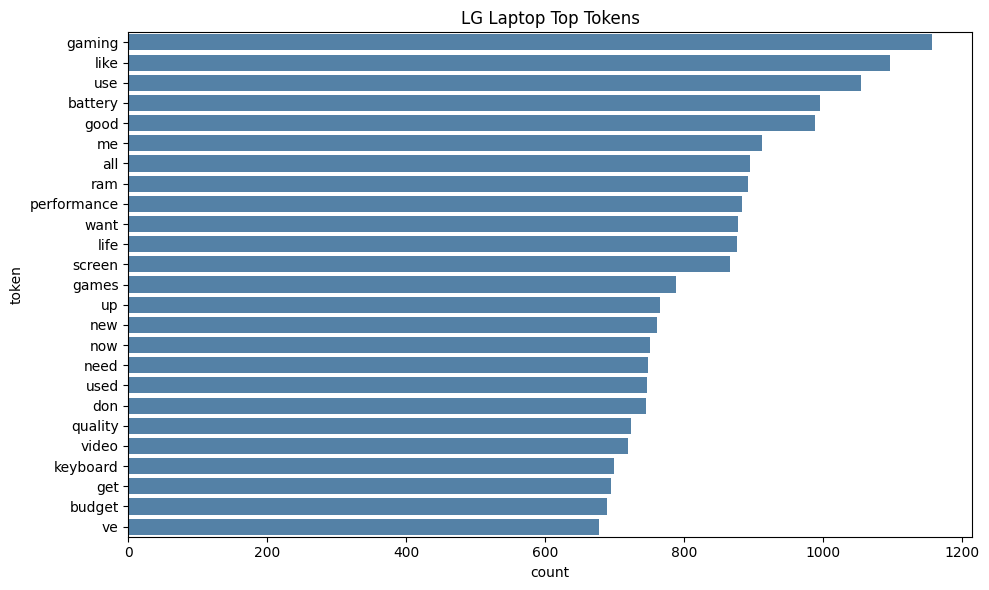

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x500 with 0 Axes>

In [ ]:
# 4. Visualization (Frequency, Aspect-Sentiment, WordClouds)
from collections import Counter

if 'tokens' not in df.columns or df['tokens'].map(len).sum() == 0:
    print('[VIS] 토큰이 없어 시각화를 건너뜁니다.')
else:
    try:
        all_tokens = list(itertools.chain.from_iterable(df['tokens']))
        if not all_tokens:
            print('[VIS] 빈 토큰 리스트 – barplot/wordcloud 스킵')
        else:
            freq = Counter(all_tokens)
            freq_df = pd.DataFrame(freq.most_common(40), columns=['token','count'])
            if not freq_df.empty:
                plt.figure(figsize=(10,6))
                sns.barplot(data=freq_df.head(25), x='count', y='token', color='steelblue')
                plt.title('LG Laptop Top Tokens'); plt.tight_layout()
                plt.savefig(DATA_DIR/'top_tokens.png', dpi=140); plt.show()
            else:
                print('[VIS] freq_df 비어있음')

            # Aspect-Sentiment matrix
            aspect_rows=[]
            if 'aspects' in df.columns and 'sentiment' in df.columns:
                for row in df.itertuples():
                    if isinstance(row.aspects, (list, tuple)):
                        for asp in row.aspects:
                            aspect_rows.append({'aspect':asp,'sentiment':row.sentiment})
            aspect_df = pd.DataFrame(aspect_rows)
            if not aspect_df.empty:
                piv = aspect_df.pivot_table(index='aspect', columns='sentiment', values='sentiment', aggfunc='count', fill_value=0)
                if piv.sum().sum() > 0:
                    piv_ratio = piv.div(piv.sum(1), axis=0)
                    plt.figure(figsize=(8,5))
                    sns.heatmap(piv_ratio, annot=True, fmt='.2f', cmap='RdYlGn')
                    plt.title('Aspect Sentiment Ratio')
                    plt.tight_layout(); plt.savefig(DATA_DIR/'aspect_sentiment_heatmap.png', dpi=150); plt.show()
                else:
                    print('[VIS] pivot 데이터 없음')
            else:
                print('[VIS] 측면(aspect) 데이터 없음')

            # WordClouds
            if freq:
                try:
                    wc_all = WordCloud(width=1100,height=550, background_color='white', colormap='viridis').generate_from_frequencies(dict(freq.most_common(150)))
                    plt.figure(figsize=(14,6)); plt.imshow(wc_all, interpolation='bilinear'); plt.axis('off'); plt.title('All Tokens WordCloud')
                    plt.savefig(DATA_DIR/'wordcloud_all.png', dpi=140, bbox_inches='tight'); plt.show()
                except ValueError as e:
                    print('[VIS] WordCloud 전체 생성 실패:', e)
            else:
                print('[VIS] WordCloud 생성을 위한 단어 없음')

            for label, cmap in [('positive','Greens'),('negative','Reds')]:
                subset = df.loc[df.get('sentiment')==label,'combined_text'] if 'sentiment' in df.columns else pd.Series(dtype=str)
                if subset.empty: continue
                try:
                    txt = ' '.join(subset)
                    if txt.strip():
                        wc = WordCloud(width=1000,height=500, background_color='white', colormap=cmap).generate(txt)
                        plt.figure(figsize=(12,5)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.title(f'{label.title()} WordCloud')
                        plt.savefig(DATA_DIR/f'wordcloud_{label}.png', dpi=140, bbox_inches='tight'); plt.show()
                except ValueError as e:
                    print(f'[VIS] {label} 워드클라우드 실패:', e)

            # Pros / Cons quick display
            if 'pros_df' in globals():
                print('Top Pros sample:')
                try:
                    print(pros_df.head(5))
                except Exception as e:
                    print('Pros 출력 실패:', e)
            if 'cons_df' in globals():
                print('\nTop Cons sample:')
                try:
                    print(cons_df.head(5))
                except Exception as e:
                    print('Cons 출력 실패:', e)

    except Exception as e:
        print('[VIS] 전체 시각화 블록 오류:', e)


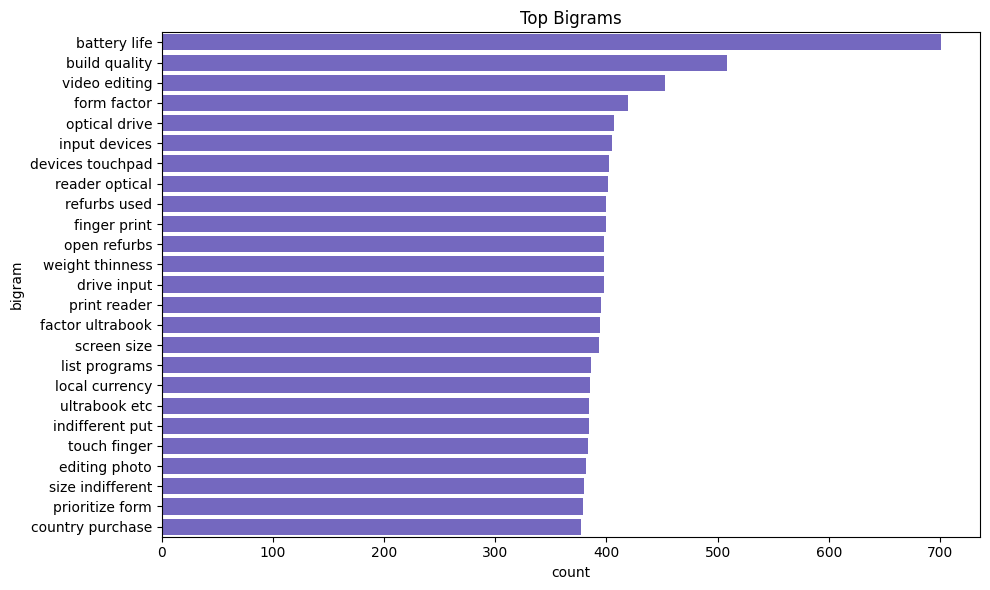

TypeError: '>=' not supported between instances of 'str' and 'int'

In [ ]:
# 5. Bigrams & Pros/Cons Aggregation
from itertools import tee
from collections import Counter

if 'tokens' not in df.columns or df['tokens'].map(len).sum() == 0:
    print('[BIGRAM] 토큰이 없어 bigram 계산을 건너뜁니다.')
else:
    def generate_bigrams(tokens):
        a,b = tee(tokens)
        next(b, None)
        return list(zip(a,b))

    all_bigrams = []
    for toks in df['tokens']:
        all_bigrams.extend(generate_bigrams(toks))

    if all_bigrams:
        bigram_counts = Counter(all_bigrams)
        bigram_df = pd.DataFrame([( ' '.join(k), v) for k,v in bigram_counts.most_common(40)], columns=['bigram','count'])
        if not bigram_df.empty:
            plt.figure(figsize=(10,6))
            sns.barplot(data=bigram_df.head(25), x='count', y='bigram', color='slateblue')
            plt.title('Top Bigrams')
            plt.tight_layout(); plt.savefig(DATA_DIR/'top_bigrams.png', dpi=140); plt.show()
        else:
            print('[BIGRAM] bigram_df 비어있음')
    else:
        print('[BIGRAM] 생성된 bigram 없음')

# Pros / Cons phrase ranking
STOP_SET = globals().get('STOPWORDS', set())

if 'pros_df' in globals() and isinstance(pros_df, pd.DataFrame) and not pros_df.empty:
    try:
        pros_phrases = (pros_df['text'].astype(str).str.lower()
                        .str.replace(r'[^a-z0-9\s가-힣]',' ', regex=True)
                        .str.split())
        pros_flat = list(itertools.chain.from_iterable(pros_phrases))
        pros_freq = Counter([w for w in pros_flat if w not in STOP_SET and len(w)>2])
        if pros_freq:
            pros_rank = pd.DataFrame(pros_freq.most_common(25), columns=['word','count'])
            plt.figure(figsize=(8,5))
            sns.barplot(data=pros_rank, x='count', y='word', color='green')
            plt.title('Pros Keyword Frequency')
            plt.tight_layout(); plt.savefig(DATA_DIR/'pros_keywords.png', dpi=140); plt.show()
        else:
            print('[PROS] 유의미 단어 없음')
    except Exception as e:
        print('[PROS] 처리 오류:', e)
else:
    print('[PROS] pros_df 비어있음 또는 없음')

if 'cons_df' in globals() and isinstance(cons_df, pd.DataFrame) and not cons_df.empty:
    try:
        cons_phrases = (cons_df['text'].astype(str).str.lower()
                        .str.replace(r'[^a-z0-9\s가-힣]',' ', regex=True)
                        .str.split())
        cons_flat = list(itertools.chain.from_iterable(cons_phrases))
        cons_freq = Counter([w for w in cons_flat if w not in STOP_SET and len(w)>2])
        if cons_freq:
            cons_rank = pd.DataFrame(cons_freq.most_common(25), columns=['word','count'])
            plt.figure(figsize=(8,5))
            sns.barplot(data=cons_rank, x='count', y='word', color='red')
            plt.title('Cons Keyword Frequency')
            plt.tight_layout(); plt.savefig(DATA_DIR/'cons_keywords.png', dpi=140); plt.show()
        else:
            print('[CONS] 유의미 단어 없음')
    except Exception as e:
        print('[CONS] 처리 오류:', e)
else:
    print('[CONS] cons_df 비어있음 또는 없음')

# Save summary artifacts (if variables exist)
try:
    if 'freq_df' in globals() and isinstance(freq_df, pd.DataFrame):
        freq_df.to_csv(DATA_DIR/'token_frequency_top40.csv', index=False, encoding='utf-8-sig')
    if 'bigram_df' in locals():
        bigram_df.to_csv(DATA_DIR/'bigram_top40.csv', index=False, encoding='utf-8-sig')
    if 'piv' in globals():
        piv.to_csv(DATA_DIR/'aspect_sentiment_counts.csv', encoding='utf-8-sig')
    print('Saved frequency, bigram, and aspect sentiment files (가능한 것만 저장).')
except Exception as e:
    print('[SAVE] 요약 저장 실패:', e)
